In [1]:
import sys
sys.path.append('../')


In [2]:
from predictor.sri_lanka_functions import lka_data_preparation
from predictor.classification_class import Classification

In [3]:
t = "overall_mar"
country = "LKA"
versioning="v3"

In [4]:

y, data_all = lka_data_preparation(new_features_fp="data/lka/sri_lanka_features19_updated.csv", targets_fp="data/lka/ML_targets_lka_updated.csv", t=t)

In [5]:
data_all.drop(columns=["r3q", "rfh_avg", "food_exp_share"], inplace=True)

In [6]:
data_all

,asset1,asset7,asset8,education2,food group1,food group2,food group3,food group4,food group5,food group6,food group7,food group8,food group9,housing1,housing2,housing4,labour1,labour2,labour4
hhid,,,,,,,,,,,,,,,,,,,
11108811,1.0,0.0,0.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,1.0
11108831,1.0,1.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,0.0
11108851,0.0,0.0,0.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,0.0
11108861,1.0,1.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,1.0
11108871,1.0,1.0,0.0,5.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19208561,1.0,0.0,0.0,4.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
19208571,0.0,0.0,0.0,4.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
19208581,1.0,1.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0


In [7]:
import xgb_pathfinder
import pandas as pd
from xgboost import XGBClassifier
import numpy as np

from predictor.classification_class import Classification


In [8]:
best_params = pd.read_csv('data\\results\\besthyper_overall_mar_LKA_undersampling_v3_xgboost.csv', index_col=0).T.to_dict()[0]
best_params = dict(best_params)

perf = pd.read_csv('data\\results\\perf_overall_mar_LKA_undersampling_v3_xgboost.csv', index_col=0)


In [9]:
perf

,accuracy,balanced accuracy,adj_balanced_accuracy,recall,precision,specificity,f1_score,target,country,sampling,feat_version,algorithm,best_random_state
mean,0.64720,0.647600,0.295200,0.62320,0.665600,0.328200,0.643800,overall_mar,LKA,undersampling,v3,xgboost,989
std,0.00507,0.005595,0.010354,0.00991,0.008081,0.010986,0.008167,overall_mar,LKA,undersampling,v3,xgboost,989


In [10]:

model = XGBClassifier(random_state=perf['best_random_state']['mean'], callbacks=None, **best_params)  # base_score=0.3, objective='binary:logistic')


In [11]:
clf_lka = Classification(y, 
                         data_all, 
                         t, 
                         'cpu', 
                         random_state=perf['best_random_state']['mean'], 
                         sampling='undersampling',
                         sampling_strategy=1)

In [12]:
train_test = clf_lka.train_test

In [13]:
X_train = np.ascontiguousarray(
    clf_lka.train_test["X_train"].to_numpy(dtype=np.float32)
)
y_train = np.ascontiguousarray(
    np.asarray(clf_lka.train_test["Y_train"], dtype=np.int32).reshape(-1)
)

model = XGBClassifier(
    random_state=int(perf["best_random_state"]["mean"]),
    callbacks=None,
    n_jobs=1,
    **best_params,
 )

In [14]:
model.fit(X_train, y_train)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,'gbtree'
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [15]:
exp = xgb_pathfinder.ModelExplainer(

    booster=model.get_booster(),

    X_train=X_train,

    y_train=y_train,

    feature_names=list(clf_lka.train_test["X_train"].columns),

    sample_ids=clf_lka.train_test["X_train"].index,

)

In [16]:
cohorts = exp.extract_cohorts()

cohorts.head()

,cohort_id,scope_signature,decider_feature_name,decider_feature_index,support_count,risk_rate,mean_confidence,late_decider_rate,decision_impact,impact_magnitude_ratio,leaf_values,top_features_by_shap,contributing_rules
0,cohort_0,food group6 < 1.00,food group4,7,5532,0.945770,0.941214,0.0,0.069464,6.401248,"[0.0854469836, 0.0814971626, 0.0779837519, 0.0...",[],"[tree_0_path_0, tree_1_path_0, tree_2_path_0, ..."
1,cohort_43,food group6 < 1.00 AND food group5 < 1.00,food group9,12,942,1.000000,0.993849,0.0,0.064078,5.904903,"[0.0708061084, 0.0674123541, 0.0647875443, 0.0...",[],"[tree_8_path_8, tree_10_path_8, tree_12_path_1..."
2,cohort_33,food group6 < 1.00 AND food group4 < 1.00,food group5,8,801,0.989446,0.984687,0.0,0.061035,5.624501,"[0.0669101775, 0.0601632483, 0.0590556376, 0.0...",[],"[tree_7_path_9, tree_16_path_0, tree_17_path_0..."
3,cohort_25,food group6 < 1.00 AND food group4 < 1.00 AND ...,food group9,12,580,0.896552,0.892849,1.0,0.058821,5.420423,"[0.0753749236, 0.0443605371, 0.072936289, 0.04...",[],"[tree_4_path_9, tree_4_path_10, tree_5_path_9,..."
4,cohort_4,food group6 < 1.00 AND food group4 < 1.00,food group3,6,2471,0.929849,0.924780,0.0,0.055343,5.099961,"[0.0741935521, 0.0515169017, 0.057243336, 0.05...",[],"[tree_0_path_9, tree_11_path_9, tree_12_path_0..."


In [17]:
cohorts.sort_values(by="risk_rate")[cohorts["support_count"] > 10000]

C:\Users\andreas\AppData\Local\Temp\ipykernel_4996\144123634.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cohorts.sort_values(by="risk_rate")[cohorts["support_count"] > 10000]


,cohort_id,scope_signature,decider_feature_name,decider_feature_index,support_count,risk_rate,mean_confidence,late_decider_rate,decision_impact,impact_magnitude_ratio,leaf_values,top_features_by_shap,contributing_rules
277,cohort_294,food group5 < 1.00 AND food group3 < 1.00 AND ...,education2,3,13624,0.284792,0.289333,1.0,0.010744,0.990033,"[-0.0191975404, -0.00945754442, -0.0183275994,...",[],"[tree_50_path_20, tree_50_path_21, tree_54_pat..."
702,cohort_507,food group2 < 1.00 AND food group4 < 1.00 AND ...,labour4,18,13139,0.297816,0.300486,1.0,0.002187,0.201504,"[-0.00166658068, -0.00562293595, -0.0002823887...",[],"[tree_106_path_15, tree_106_path_16, tree_151_..."
44,cohort_37,food group6 < 1.00 AND food group4 < 1.00 AND ...,food group3,6,10665,0.369339,0.370924,1.0,0.022370,2.061463,"[-0.0152168125, -0.0393923, -0.0107676229, -0....",[],"[tree_7_path_16, tree_7_path_17, tree_15_path_..."
145,cohort_107,food group4 < 1.00 AND food group6 < 1.00 AND ...,food group3,6,10665,0.369339,0.370924,1.0,0.014521,1.338153,"[-0.00847377814, -0.0259520058, -0.00663232151...",[],"[tree_20_path_18, tree_20_path_19, tree_26_pat..."
544,cohort_171,food group5 < 1.00 AND asset1 < 1.00 AND food ...,education2,3,10216,0.383908,0.385938,1.0,0.005976,0.550668,"[0.00445227278, -0.00800169725, 0.00427813642,...",[],"[tree_30_path_15, tree_30_path_16, tree_33_pat..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
706,cohort_327,food group9 < 1.00 AND education2 < 5.00 AND f...,labour4,18,10048,0.638734,0.637941,1.0,0.002111,0.194518,"[0.00412940653, -0.00052029395, 0.00309466361,...",[],"[tree_56_path_11, tree_56_path_12, tree_70_pat..."
42,cohort_22,food group6 < 1.00 AND food group4 < 1.00 AND ...,asset1,0,15800,0.674051,0.670762,1.0,0.022409,2.064979,"[0.0369172171, 0.0185819454, 0.0322033688, 0.0...",[],"[tree_4_path_3, tree_4_path_4, tree_7_path_3, ..."
40,cohort_41,food group6 < 1.00 AND food group4 < 1.00 AND ...,education2,3,12584,0.674825,0.672260,1.0,0.023080,2.126896,"[0.0343455896, 0.0184025448, 0.0317466483, 0.0...",[],"[tree_8_path_3, tree_8_path_4, tree_10_path_3,..."
119,cohort_303,food group2 < 1.00,labour1,16,10571,0.988270,0.983702,0.0,0.015795,1.455556,"[0.0448489599, 0.00526998052, 0.0435894392, 0....",[],"[tree_52_path_0, tree_52_path_1, tree_55_path_..."


In [18]:
hh_mapping = pd.read_csv("data/lka/hh_geo_mapping.csv")

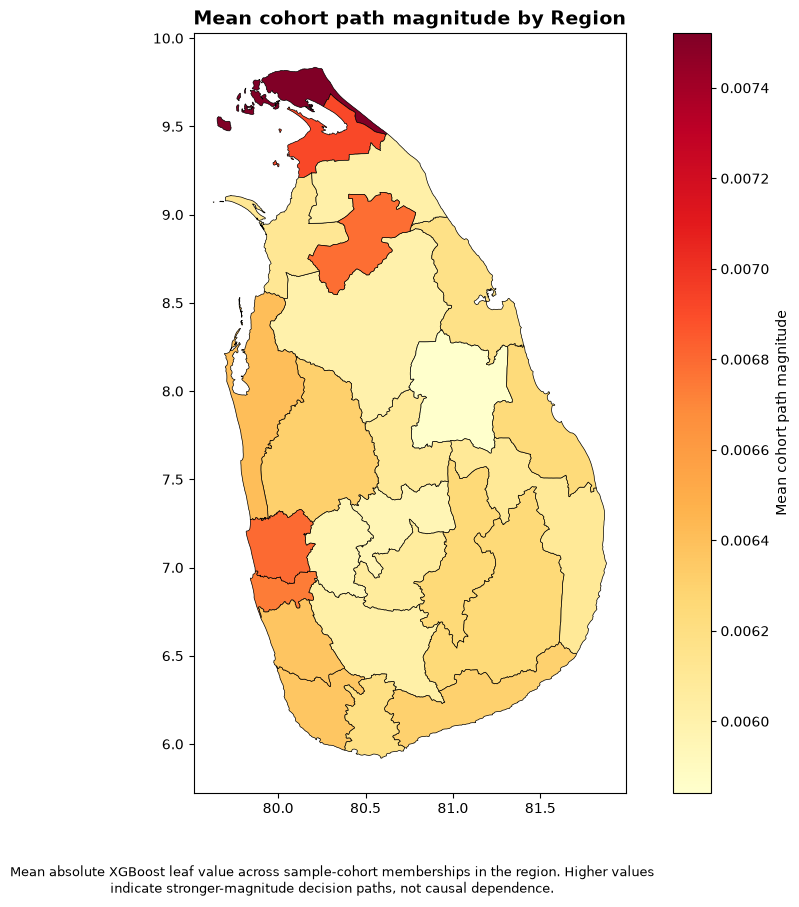

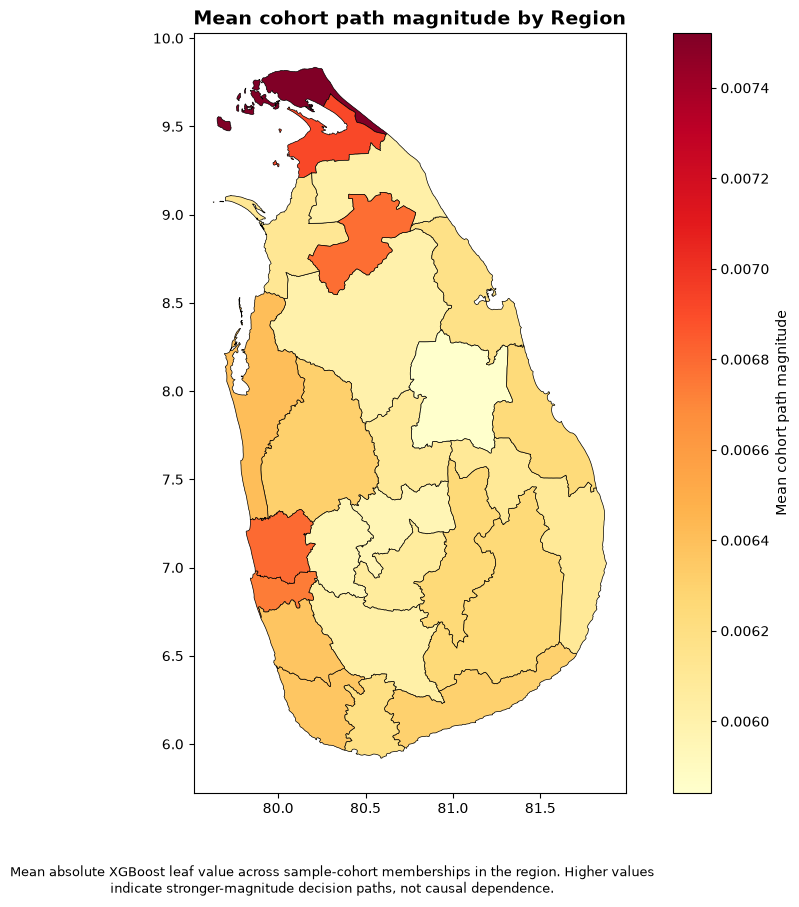

In [ ]:
exp.plot_geographic_impact(
    "data/lka/geodata_sri_lanka.csv",
    hh_mapping,
    
)

In [22]:
cohorts

,cohort_id,scope_signature,decider_feature_name,decider_feature_index,support_count,risk_rate,mean_confidence,late_decider_rate,decision_impact,impact_magnitude_ratio,leaf_values,top_features_by_shap,contributing_rules
0,cohort_0,food group6 < 1.00,food group4,7,5532,0.945770,0.941214,0.0,0.069464,6.401248,"[0.0854469836, 0.0814971626, 0.0779837519, 0.0...",[],"[tree_0_path_0, tree_1_path_0, tree_2_path_0, ..."
1,cohort_43,food group6 < 1.00 AND food group5 < 1.00,food group9,12,942,1.000000,0.993849,0.0,0.064078,5.904903,"[0.0708061084, 0.0674123541, 0.0647875443, 0.0...",[],"[tree_8_path_8, tree_10_path_8, tree_12_path_1..."
2,cohort_33,food group6 < 1.00 AND food group4 < 1.00,food group5,8,801,0.989446,0.984687,0.0,0.061035,5.624501,"[0.0669101775, 0.0601632483, 0.0590556376, 0.0...",[],"[tree_7_path_9, tree_16_path_0, tree_17_path_0..."
3,cohort_25,food group6 < 1.00 AND food group4 < 1.00 AND ...,food group9,12,580,0.896552,0.892849,1.0,0.058821,5.420423,"[0.0753749236, 0.0443605371, 0.072936289, 0.04...",[],"[tree_4_path_9, tree_4_path_10, tree_5_path_9,..."
4,cohort_4,food group6 < 1.00 AND food group4 < 1.00,food group3,6,2471,0.929849,0.924780,0.0,0.055343,5.099961,"[0.0741935521, 0.0515169017, 0.057243336, 0.05...",[],"[tree_0_path_9, tree_11_path_9, tree_12_path_0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,cohort_667,food group2 < 1.00 AND food group4 < 1.00 AND ...,education2,3,50296,0.501193,0.500943,1.0,0.000418,0.038481,"[-0.00063529308, 0.000219322261, -0.0006130709...",[],"[tree_160_path_12, tree_160_path_13, tree_163_..."
746,cohort_718,food group2 < 1.00 AND food group8 < 1.00 AND ...,education2,3,38961,0.508355,0.508093,1.0,0.000381,0.035068,"[0.000692084606, -0.000113859773, 0.0006299514...",[],"[tree_180_path_14, tree_180_path_15, tree_189_..."
747,cohort_645,food group1 < 1.00 AND food group4 < 1.00 AND ...,labour2,17,12584,0.501271,0.501096,1.0,0.000361,0.033291,"[-0.000377243385, 0.000345290784]",[],"[tree_150_path_15, tree_150_path_16]"
748,cohort_721,food group2 < 1.00 AND food group8 < 1.00 AND ...,asset1,0,51948,0.508355,0.508093,1.0,0.000335,0.030848,"[0.000485062279, -0.0002123452, 0.000463668082...",[],"[tree_183_path_13, tree_183_path_14, tree_185_..."


In [ ]:
exp.